In [1]:
# ================================================================================
# EXPERIMENT A: OPTIMIZER COMPARISON
# ================================================================================
# 
# Purpose: Compare L-BFGS vs Adam vs SGD vs RMSprop for Neural Style Transfer
# Baseline: V3/V4 configuration (user-preferred settings)
# 
# This notebook tests whether L-BFGS is the optimal optimizer choice.
# ================================================================================

# %% [markdown]
# # Experiment A: Optimizer Comparison
# 
# ## Objective
# Compare different optimization algorithms for Neural Style Transfer:
# - L-BFGS (current baseline)
# - Adam (adaptive learning rate)
# - SGD (basic gradient descent)
# - SGD with Momentum
# - RMSprop (adaptive learning rate)
# 
# ## Baseline Configuration (V3/V4)
# - Style Weight: 1e-4
# - Edge Weight: 0
# - Surface Weight: 10,000
# - Laplacian Weight: 0

# %% [markdown]
# ## 1. Imports and Setup

# %%
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
import time
import os
import csv
from datetime import datetime

# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Create results directory
RESULTS_DIR = 'results_optimizer_comparison'
os.makedirs(RESULTS_DIR, exist_ok=True)



TensorFlow version: 2.10.1
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Content image shape: (1, 512, 512, 3)
Style image shape: (1, 512, 512, 3)


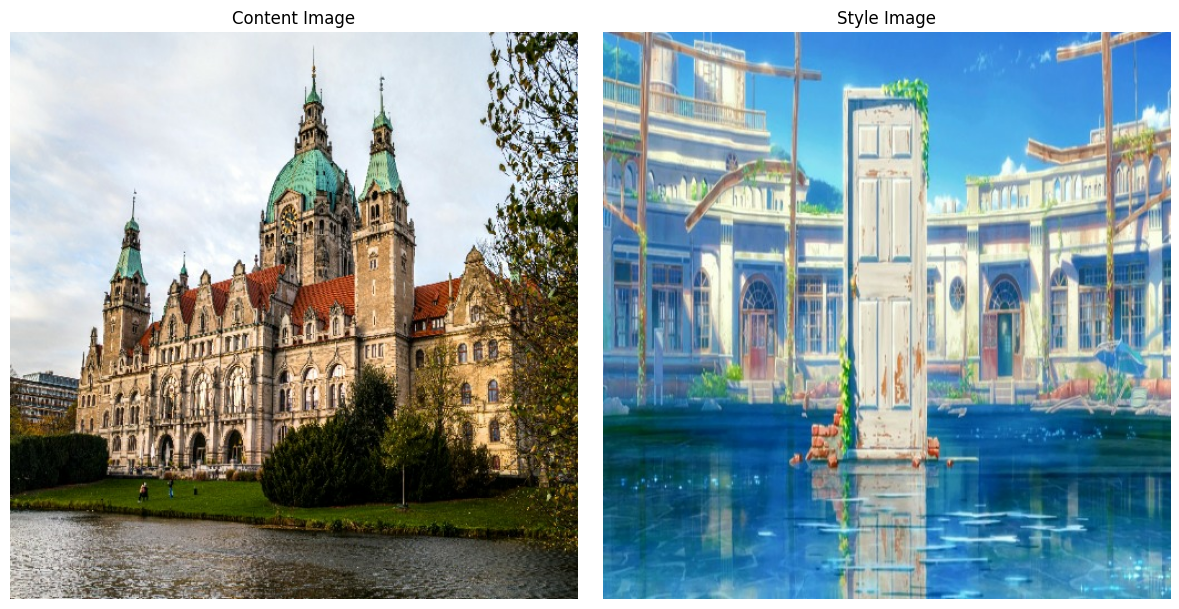

In [2]:
# 2. Image Loading and Preprocessing

def load_and_preprocess_image(image_path, target_size=(512, 512)):
    """Load and preprocess image for VGG19."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, target_size)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.vgg19.preprocess_input(img)
    return tf.expand_dims(img, axis=0)

def deprocess_image(processed_img):
    """Convert processed image back to displayable format."""
    img = processed_img.copy()
    if len(img.shape) == 4:
        img = img[0]
    
    # Reverse VGG19 preprocessing
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]  # BGR to RGB
    
    img = np.clip(img, 0, 255).astype('uint8')
    return img

# Load images
CONTENT_PATH = 'ContentImage_512x512.jpg'
STYLE_PATH = 'Animate_512x512.jpg'

content_image = load_and_preprocess_image(CONTENT_PATH)
style_image = load_and_preprocess_image(STYLE_PATH)

print(f"Content image shape: {content_image.shape}")
print(f"Style image shape: {style_image.shape}")

# Display images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(deprocess_image(content_image.numpy()))
axes[0].set_title('Content Image')
axes[0].axis('off')
axes[1].imshow(deprocess_image(style_image.numpy()))
axes[1].set_title('Style Image')
axes[1].axis('off')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/input_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# 3. VGG19 Feature Extractor

# Define layers for style and content
CONTENT_LAYERS = ['block4_conv2']
STYLE_LAYERS = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

def build_vgg_model():
    """Build VGG19 model for feature extraction."""
    vgg = VGG19(weights='imagenet', include_top=False)
    vgg.trainable = False
    
    content_outputs = [vgg.get_layer(name).output for name in CONTENT_LAYERS]
    style_outputs = [vgg.get_layer(name).output for name in STYLE_LAYERS]
    
    model = Model(inputs=vgg.input, outputs=content_outputs + style_outputs)
    return model

vgg_model = build_vgg_model()
print("VGG19 model built successfully")
print(f"Content layers: {CONTENT_LAYERS}")
print(f"Style layers: {STYLE_LAYERS}")


VGG19 model built successfully
Content layers: ['block4_conv2']
Style layers: ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']


In [4]:
# 4. Loss Functions

def gram_matrix(tensor):
    """Compute Gram matrix for style representation."""
    # tensor shape: [batch, height, width, channels]
    batch, h, w, c = tensor.shape
    features = tf.reshape(tensor, [batch, h * w, c])
    gram = tf.matmul(features, features, transpose_a=True)
    return gram / tf.cast(h * w * c, tf.float32)

def content_loss(content_features, generated_features):
    """Compute content loss (MSE between feature maps)."""
    return tf.reduce_mean(tf.square(content_features - generated_features))

def style_loss(style_features, generated_features):
    """Compute style loss (MSE between Gram matrices)."""
    style_gram = gram_matrix(style_features)
    generated_gram = gram_matrix(generated_features)
    return tf.reduce_mean(tf.square(style_gram - generated_gram))

def compute_edge_map(image):
    """Compute edge magnitude using Sobel operators (differentiable)."""
    sobel_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
    sobel_y = tf.constant([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=tf.float32)
    
    sobel_x = tf.reshape(sobel_x, [3, 3, 1, 1])
    sobel_y = tf.reshape(sobel_y, [3, 3, 1, 1])
    
    # Convert to grayscale
    gray = tf.reduce_mean(image, axis=-1, keepdims=True)
    
    edges_x = tf.nn.conv2d(gray, sobel_x, strides=[1, 1, 1, 1], padding='SAME')
    edges_y = tf.nn.conv2d(gray, sobel_y, strides=[1, 1, 1, 1], padding='SAME')
    
    edge_magnitude = tf.sqrt(tf.square(edges_x) + tf.square(edges_y) + 1e-6)
    return edge_magnitude

def edge_loss(content_image, generated_image):
    """Compute edge preservation loss."""
    content_edges = compute_edge_map(content_image)
    generated_edges = compute_edge_map(generated_image)
    return tf.reduce_mean(tf.square(content_edges - generated_edges))

def box_filter(image, radius):
    """Apply box filter for guided filter."""
    kernel_size = 2 * radius + 1
    kernel = tf.ones([kernel_size, kernel_size, 1, 1], dtype=tf.float32)
    kernel = kernel / (kernel_size * kernel_size)
    
    channels = tf.split(image, num_or_size_splits=image.shape[-1], axis=-1)
    filtered_channels = []
    for channel in channels:
        filtered = tf.nn.conv2d(channel, kernel, strides=[1, 1, 1, 1], padding='SAME')
        filtered_channels.append(filtered)
    return tf.concat(filtered_channels, axis=-1)

def guided_filter(guidance, source, radius=4, epsilon=0.01):
    """Apply guided filter for edge-preserving smoothing."""
    mean_g = box_filter(guidance, radius)
    mean_s = box_filter(source, radius)
    
    cov_gs = box_filter(guidance * source, radius) - mean_g * mean_s
    var_g = box_filter(guidance * guidance, radius) - mean_g * mean_g
    
    a = cov_gs / (var_g + epsilon)
    b = mean_s - a * mean_g
    
    mean_a = box_filter(a, radius)
    mean_b = box_filter(b, radius)
    
    return mean_a * guidance + mean_b

def surface_loss(content_image, generated_image, radius=4, epsilon=0.01):
    """Compute surface smoothing loss using guided filter."""
    smoothed = guided_filter(content_image, generated_image, radius, epsilon)
    return tf.reduce_mean(tf.square(generated_image - smoothed))

def compute_laplacian_loss(image):
    """Compute Laplacian loss for flat regions."""
    laplacian_kernel = tf.constant([
        [0,  1, 0],
        [1, -4, 1],
        [0,  1, 0]
    ], dtype=tf.float32)
    laplacian_kernel = tf.reshape(laplacian_kernel, [3, 3, 1, 1])
    
    gray = tf.reduce_mean(image, axis=-1, keepdims=True)
    laplacian = tf.nn.conv2d(gray, laplacian_kernel, strides=[1, 1, 1, 1], padding='SAME')
    
    return tf.reduce_mean(tf.square(laplacian))

print("Loss functions defined successfully")

Loss functions defined successfully


In [5]:
# 5. Total Loss Computation

def compute_total_loss(generated_image, content_image, style_image, vgg_model, weights):
    """
    Compute total loss with all components.
    
    Args:
        generated_image: Current generated image
        content_image: Original content image
        style_image: Style reference image
        vgg_model: VGG19 feature extractor
        weights: Dictionary of loss weights
    
    Returns:
        total_loss, loss_dict (for logging)
    """
    # Extract features
    input_tensor = tf.concat([content_image, style_image, generated_image], axis=0)
    features = vgg_model(input_tensor)
    
    num_content_layers = len(CONTENT_LAYERS)
    content_features = features[:num_content_layers]
    style_features = features[num_content_layers:]
    
    # Content loss
    c_loss = 0
    for i, layer_features in enumerate(content_features):
        content_feat = layer_features[0:1]  # Content image features
        generated_feat = layer_features[2:3]  # Generated image features
        c_loss += content_loss(content_feat, generated_feat)
    c_loss /= len(CONTENT_LAYERS)
    
    # Style loss
    s_loss = 0
    for i, layer_features in enumerate(style_features):
        style_feat = layer_features[1:2]  # Style image features
        generated_feat = layer_features[2:3]  # Generated image features
        s_loss += style_loss(style_feat, generated_feat)
    s_loss /= len(STYLE_LAYERS)
    
    # Total variation loss
    tv_loss = tf.image.total_variation(generated_image)
    
    # Edge loss
    e_loss = edge_loss(content_image, generated_image) if weights['edge'] > 0 else 0
    
    # Surface loss
    surf_loss = surface_loss(content_image, generated_image) if weights['surface'] > 0 else 0
    
    # Laplacian loss
    lap_loss = compute_laplacian_loss(generated_image) if weights['laplacian'] > 0 else 0
    
    # Total weighted loss
    total = (weights['content'] * c_loss + 
             weights['style'] * s_loss + 
             weights['tv'] * tv_loss +
             weights['edge'] * e_loss +
             weights['surface'] * surf_loss +
             weights['laplacian'] * lap_loss)
    
    loss_dict = {
        'total': float(total),
        'content': float(c_loss),
        'style': float(s_loss),
        'tv': float(tv_loss),
        'edge': float(e_loss) if weights['edge'] > 0 else 0,
        'surface': float(surf_loss) if weights['surface'] > 0 else 0,
        'laplacian': float(lap_loss) if weights['laplacian'] > 0 else 0
    }
    
    return total, loss_dict


In [6]:
# 6. Evaluation Metrics

from skimage.metrics import structural_similarity as ssim
from skimage.feature import canny
import cv2

def compute_edge_ssim(original, generated):
    """Compute Edge SSIM between original and generated images."""
    # Convert to grayscale
    if len(original.shape) == 3:
        orig_gray = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
        gen_gray = cv2.cvtColor(generated, cv2.COLOR_RGB2GRAY)
    else:
        orig_gray = original
        gen_gray = generated
    
    # Apply Canny edge detection
    orig_edges = canny(orig_gray, sigma=1.0).astype(float)
    gen_edges = canny(gen_gray, sigma=1.0).astype(float)
    
    # Compute SSIM on edge maps
    score = ssim(orig_edges, gen_edges, data_range=1.0)
    return score

def compute_flatness(image):
    """Compute flatness score using Laplacian variance."""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image
    
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    variance = laplacian.var()
    flatness = 1.0 / (1.0 + variance / 500.0)
    return flatness

def compute_color_variance(image, patch_size=8):
    """Compute mean color variance across patches."""
    h, w, c = image.shape
    variances = []
    
    for i in range(0, h - patch_size, patch_size):
        for j in range(0, w - patch_size, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size, :]
            var = np.var(patch)
            variances.append(var)
    
    return np.mean(variances)

def compute_gradient_magnitude(image):
    """Compute mean gradient magnitude."""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(float)
    else:
        gray = image.astype(float)
    
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    return np.mean(magnitude)

def evaluate_image(original, generated):
    """Compute all evaluation metrics."""
    return {
        'edge_ssim': compute_edge_ssim(original, generated),
        'flatness': compute_flatness(generated),
        'color_variance': compute_color_variance(generated),
        'gradient_magnitude': compute_gradient_magnitude(generated)
    }

print("Evaluation metrics defined successfully")


Evaluation metrics defined successfully


In [7]:
# 7. Optimizer Implementations

# V3/V4 Baseline Configuration
BASELINE_WEIGHTS = {
    'content': 2.5e-8,
    'style': 1e-4,
    'tv': 1e-6,
    'edge': 0,          # Disabled for V3/V4
    'surface': 10000,
    'laplacian': 0      # Disabled for V3/V4
}

print("Baseline weights (V3/V4 configuration):")
for k, v in BASELINE_WEIGHTS.items():
    print(f"  {k}: {v}")


def run_lbfgs_optimization(content_image, style_image, vgg_model, weights, iterations=20):
    """
    Run L-BFGS optimization (current baseline method).
    """
    from scipy.optimize import fmin_l_bfgs_b
    
    print("\n" + "="*60)
    print("Running L-BFGS Optimization")
    print("="*60)
    
    # Initialize from content image
    generated = tf.Variable(content_image, dtype=tf.float32)
    
    img_shape = content_image.shape
    
    loss_history = []
    
    class Evaluator:
        def __init__(self):
            self.loss_value = None
            self.grads_value = None
        
        def loss(self, x):
            x = x.reshape(img_shape).astype('float32')
            x_tensor = tf.constant(x)
            
            with tf.GradientTape() as tape:
                tape.watch(x_tensor)
                loss, loss_dict = compute_total_loss(x_tensor, content_image, style_image, vgg_model, weights)
            
            grads = tape.gradient(loss, x_tensor)
            
            self.loss_value = float(loss)
            self.grads_value = grads.numpy().flatten().astype('float64')
            loss_history.append(self.loss_value)
            
            return self.loss_value
        
        def grads(self, x):
            return self.grads_value
    
    evaluator = Evaluator()
    x = content_image.numpy().flatten().astype('float64')
    
    start_time = time.time()
    
    for i in range(iterations):
        x, loss, info = fmin_l_bfgs_b(
            evaluator.loss,
            x,
            fprime=evaluator.grads,
            maxfun=20
        )
        print(f"  Iteration {i+1}/{iterations}: Loss = {loss:.4f}")
    
    elapsed_time = time.time() - start_time
    
    result_image = x.reshape(img_shape)
    
    return result_image, loss_history, elapsed_time


def run_adam_optimization(content_image, style_image, vgg_model, weights, 
                          learning_rate=0.01, iterations=300):
    """
    Run Adam optimization.
    """
    print("\n" + "="*60)
    print(f"Running Adam Optimization (LR={learning_rate}, iterations={iterations})")
    print("="*60)
    
    # Initialize from content image
    generated = tf.Variable(content_image, dtype=tf.float32)
    
    optimizer = tf.optimizers.Adam(learning_rate=learning_rate)
    
    loss_history = []
    start_time = time.time()
    
    for i in range(iterations):
        with tf.GradientTape() as tape:
            loss, loss_dict = compute_total_loss(generated, content_image, style_image, vgg_model, weights)
        
        grads = tape.gradient(loss, generated)
        optimizer.apply_gradients([(grads, generated)])
        
        loss_history.append(float(loss))
        
        if (i + 1) % 50 == 0 or i == 0:
            print(f"  Iteration {i+1}/{iterations}: Loss = {float(loss):.4f}")
    
    elapsed_time = time.time() - start_time
    
    return generated.numpy(), loss_history, elapsed_time


def run_sgd_optimization(content_image, style_image, vgg_model, weights,
                         learning_rate=0.01, momentum=0.0, iterations=300):
    """
    Run SGD optimization (with optional momentum).
    """
    print("\n" + "="*60)
    print(f"Running SGD Optimization (LR={learning_rate}, momentum={momentum}, iterations={iterations})")
    print("="*60)
    
    # Initialize from content image
    generated = tf.Variable(content_image, dtype=tf.float32)
    
    optimizer = tf.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    
    loss_history = []
    start_time = time.time()
    
    for i in range(iterations):
        with tf.GradientTape() as tape:
            loss, loss_dict = compute_total_loss(generated, content_image, style_image, vgg_model, weights)
        
        grads = tape.gradient(loss, generated)
        optimizer.apply_gradients([(grads, generated)])
        
        loss_history.append(float(loss))
        
        if (i + 1) % 50 == 0 or i == 0:
            print(f"  Iteration {i+1}/{iterations}: Loss = {float(loss):.4f}")
    
    elapsed_time = time.time() - start_time
    
    return generated.numpy(), loss_history, elapsed_time


def run_rmsprop_optimization(content_image, style_image, vgg_model, weights,
                             learning_rate=0.01, iterations=300):
    """
    Run RMSprop optimization.
    """
    print("\n" + "="*60)
    print(f"Running RMSprop Optimization (LR={learning_rate}, iterations={iterations})")
    print("="*60)
    
    # Initialize from content image
    generated = tf.Variable(content_image, dtype=tf.float32)
    
    optimizer = tf.optimizers.RMSprop(learning_rate=learning_rate)
    
    loss_history = []
    start_time = time.time()
    
    for i in range(iterations):
        with tf.GradientTape() as tape:
            loss, loss_dict = compute_total_loss(generated, content_image, style_image, vgg_model, weights)
        
        grads = tape.gradient(loss, generated)
        optimizer.apply_gradients([(grads, generated)])
        
        loss_history.append(float(loss))
        
        if (i + 1) % 50 == 0 or i == 0:
            print(f"  Iteration {i+1}/{iterations}: Loss = {float(loss):.4f}")
    
    elapsed_time = time.time() - start_time
    
    return generated.numpy(), loss_history, elapsed_time

Baseline weights (V3/V4 configuration):
  content: 2.5e-08
  style: 0.0001
  tv: 1e-06
  edge: 0
  surface: 10000
  laplacian: 0


In [8]:
# 8. Run All Experiments

# Define experiment configurations
EXPERIMENTS = [
    {'name': 'L-BFGS', 'optimizer': 'lbfgs', 'lr': None, 'momentum': None, 'iterations': 20},
    {'name': 'Adam_lr0.01', 'optimizer': 'adam', 'lr': 0.01, 'momentum': None, 'iterations': 300},
    {'name': 'Adam_lr0.001', 'optimizer': 'adam', 'lr': 0.001, 'momentum': None, 'iterations': 300},
    {'name': 'Adam_lr0.0001', 'optimizer': 'adam', 'lr': 0.0001, 'momentum': None, 'iterations': 300},
    {'name': 'SGD_lr0.1', 'optimizer': 'sgd', 'lr': 0.1, 'momentum': 0.0, 'iterations': 300},
    {'name': 'SGD_lr0.01', 'optimizer': 'sgd', 'lr': 0.01, 'momentum': 0.0, 'iterations': 300},
    {'name': 'SGD_lr0.001', 'optimizer': 'sgd', 'lr': 0.001, 'momentum': 0.0, 'iterations': 300},
    {'name': 'SGD_momentum', 'optimizer': 'sgd', 'lr': 0.01, 'momentum': 0.9, 'iterations': 300},
    {'name': 'RMSprop_lr0.01', 'optimizer': 'rmsprop', 'lr': 0.01, 'momentum': None, 'iterations': 300},
    {'name': 'RMSprop_lr0.001', 'optimizer': 'rmsprop', 'lr': 0.001, 'momentum': None, 'iterations': 300},
]

print(f"Total experiments to run: {len(EXPERIMENTS)}")
for exp in EXPERIMENTS:
    print(f"  - {exp['name']}")


# Run all experiments
results = []
original_image = deprocess_image(content_image.numpy())

for exp in EXPERIMENTS:
    print(f"\n{'#'*70}")
    print(f"# EXPERIMENT: {exp['name']}")
    print(f"{'#'*70}")
    
    try:
        if exp['optimizer'] == 'lbfgs':
            result_image, loss_history, elapsed_time = run_lbfgs_optimization(
                content_image, style_image, vgg_model, BASELINE_WEIGHTS, 
                iterations=exp['iterations']
            )
        elif exp['optimizer'] == 'adam':
            result_image, loss_history, elapsed_time = run_adam_optimization(
                content_image, style_image, vgg_model, BASELINE_WEIGHTS,
                learning_rate=exp['lr'], iterations=exp['iterations']
            )
        elif exp['optimizer'] == 'sgd':
            result_image, loss_history, elapsed_time = run_sgd_optimization(
                content_image, style_image, vgg_model, BASELINE_WEIGHTS,
                learning_rate=exp['lr'], momentum=exp['momentum'], iterations=exp['iterations']
            )
        elif exp['optimizer'] == 'rmsprop':
            result_image, loss_history, elapsed_time = run_rmsprop_optimization(
                content_image, style_image, vgg_model, BASELINE_WEIGHTS,
                learning_rate=exp['lr'], iterations=exp['iterations']
            )
        
        # Deprocess and evaluate
        output_image = deprocess_image(result_image)
        metrics = evaluate_image(original_image, output_image)
        
        # Store results
        result = {
            'name': exp['name'],
            'optimizer': exp['optimizer'],
            'learning_rate': exp['lr'],
            'momentum': exp['momentum'],
            'iterations': exp['iterations'],
            'time_seconds': elapsed_time,
            'final_loss': loss_history[-1],
            'edge_ssim': metrics['edge_ssim'],
            'flatness': metrics['flatness'],
            'color_variance': metrics['color_variance'],
            'gradient_magnitude': metrics['gradient_magnitude'],
            'loss_history': loss_history,
            'output_image': output_image
        }
        results.append(result)
        
        # Save individual result image
        plt.figure(figsize=(8, 8))
        plt.imshow(output_image)
        plt.title(f"{exp['name']}\nEdge SSIM: {metrics['edge_ssim']:.3f}, Flatness: {metrics['flatness']:.3f}")
        plt.axis('off')
        plt.savefig(f"{RESULTS_DIR}/{exp['name']}.png", dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"\n  Results for {exp['name']}:")
        print(f"    Time: {elapsed_time:.2f} seconds")
        print(f"    Final Loss: {loss_history[-1]:.4f}")
        print(f"    Edge SSIM: {metrics['edge_ssim']:.4f}")
        print(f"    Flatness: {metrics['flatness']:.4f}")
        print(f"    Color Variance: {metrics['color_variance']:.2f}")
        
    except Exception as e:
        print(f"  ERROR in {exp['name']}: {str(e)}")
        continue

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED")
print("="*70)

Total experiments to run: 10
  - L-BFGS
  - Adam_lr0.01
  - Adam_lr0.001
  - Adam_lr0.0001
  - SGD_lr0.1
  - SGD_lr0.01
  - SGD_lr0.001
  - SGD_momentum
  - RMSprop_lr0.01
  - RMSprop_lr0.001

######################################################################
# EXPERIMENT: L-BFGS
######################################################################

Running L-BFGS Optimization
  Iteration 1/20: Loss = 5282.4858
  Iteration 2/20: Loss = 1701.6497
  Iteration 3/20: Loss = 1011.9421
  Iteration 4/20: Loss = 727.8083
  Iteration 5/20: Loss = 540.2903
  Iteration 6/20: Loss = 435.1664
  Iteration 7/20: Loss = 380.5567
  Iteration 8/20: Loss = 335.1207
  Iteration 9/20: Loss = 301.2309
  Iteration 10/20: Loss = 276.5224
  Iteration 11/20: Loss = 256.4516
  Iteration 12/20: Loss = 237.1024
  Iteration 13/20: Loss = 222.5188
  Iteration 14/20: Loss = 205.0370
  Iteration 15/20: Loss = 192.6818
  Iteration 16/20: Loss = 180.9081
  Iteration 17/20: Loss = 171.8030
  Iteration 18/20: Loss = 

Optimizer            LR         Iter   Time(s)    Loss         Edge SSIM    Flatness  
--------------------------------------------------------------------------------
L-BFGS               N/A        20     198.89     152.5810     0.8138       0.0968    
Adam_lr0.01          0.01       300    104.80     208781.9219  0.9858       0.0754    
Adam_lr0.001         0.001      300    104.61     240147.7812  0.9891       0.0762    
Adam_lr0.0001        0.0001     300    104.32     243644.9531  0.9875       0.0765    
SGD_lr0.1            0.1        300    104.51     121483.3828  0.9817       0.0762    
SGD_lr0.01           0.01       300    104.18     224621.4844  0.9978       0.0756    
SGD_lr0.001          0.001      300    104.67     241994.9688  0.9987       0.0756    
SGD_momentum         0.01       300    104.58     122521.5625  0.9816       0.0762    
RMSprop_lr0.01       0.01       300    104.47     207012.1094  0.9848       0.0759    
RMSprop_lr0.001      0.001      300    104.80    

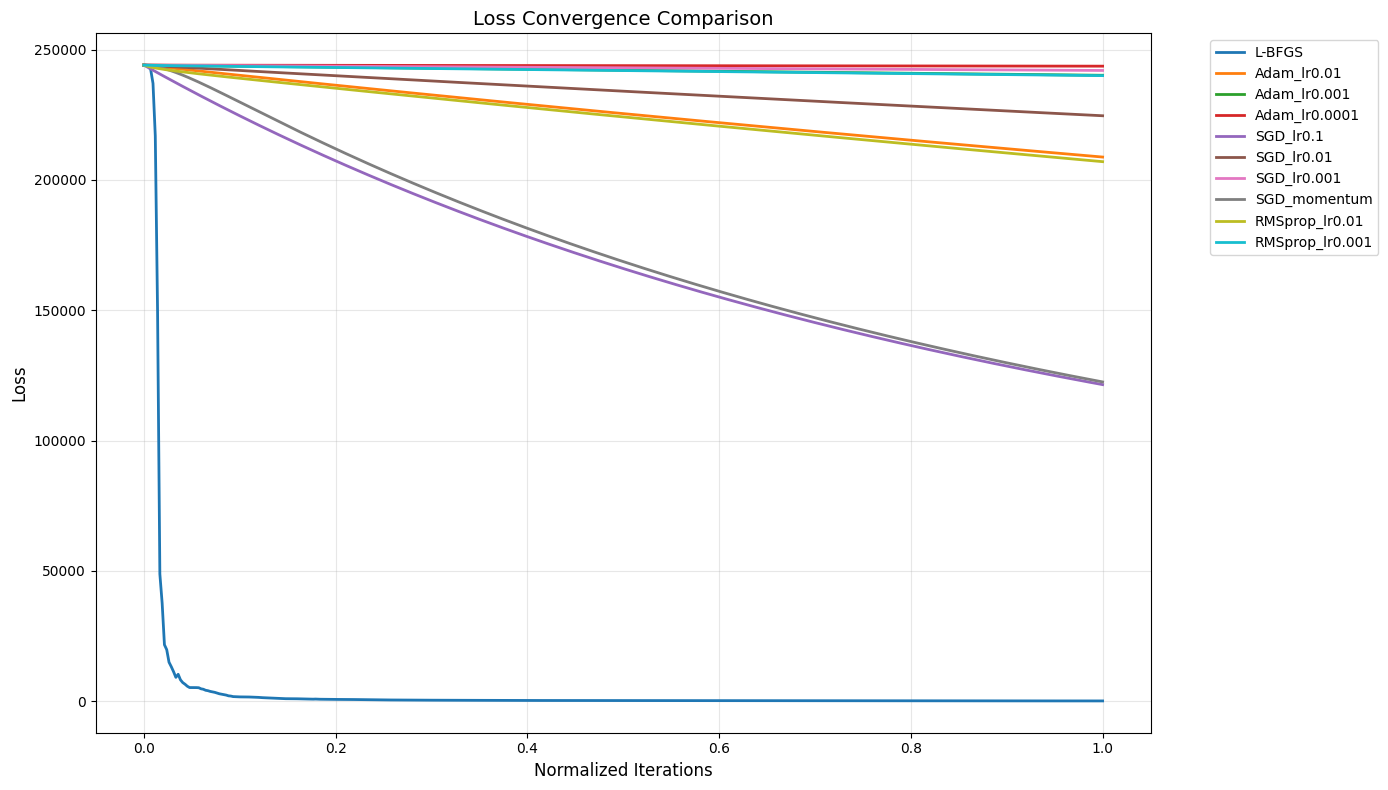

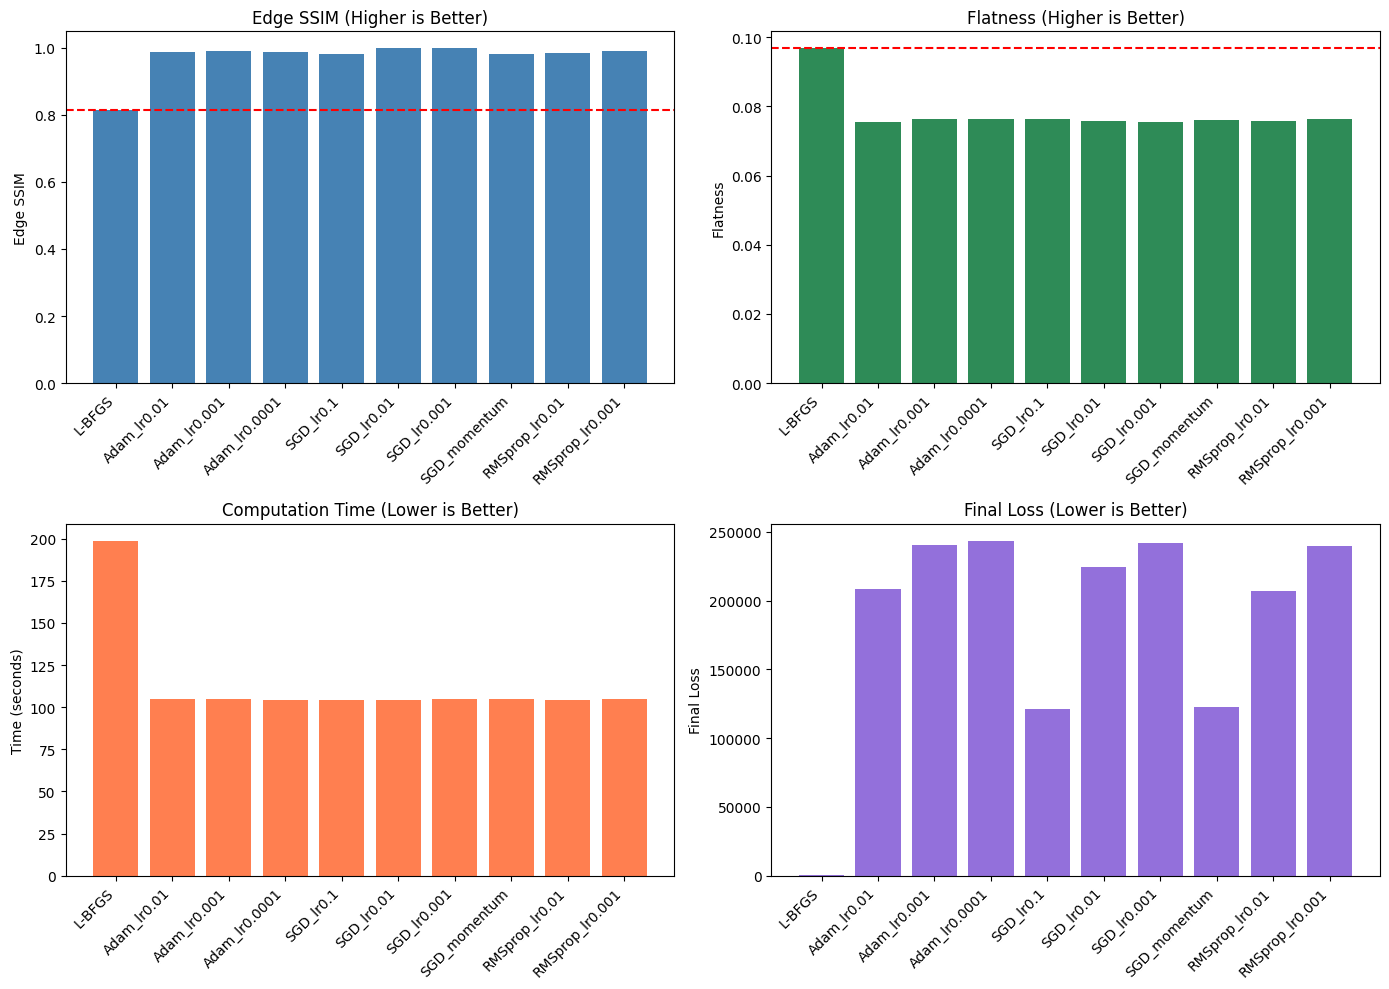

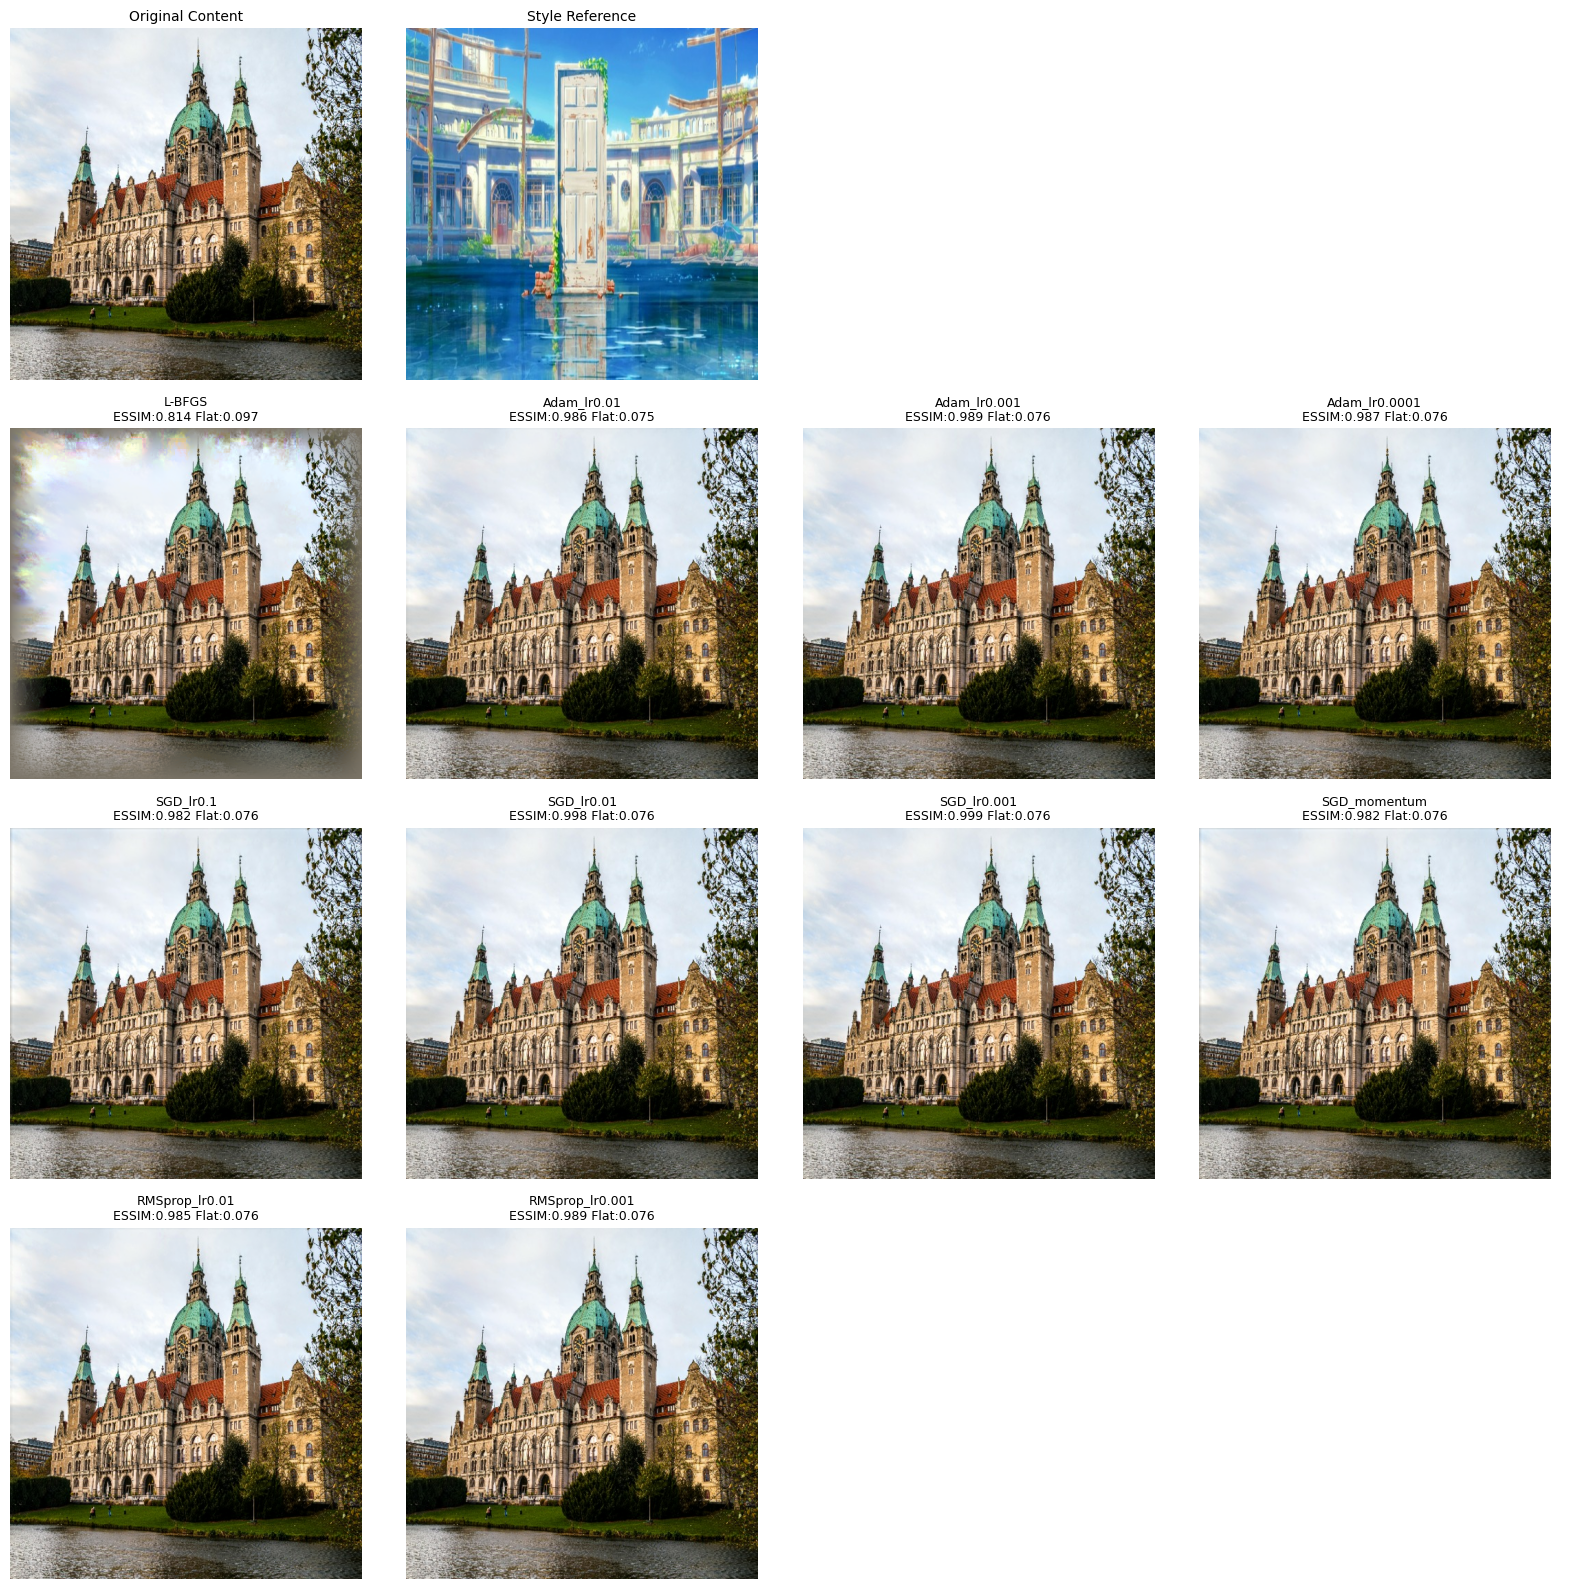

In [9]:
# 9. Results Analysis and Visualization

# Create results summary table
header = f"{'Optimizer':<20} {'LR':<10} {'Iter':<6} {'Time(s)':<10} {'Loss':<12} {'Edge SSIM':<12} {'Flatness':<10}"
print(header)
print("-" * 80)

for r in results:
    lr_str = f"{r['learning_rate']}" if r['learning_rate'] else "N/A"
    print(f"{r['name']:<20} {lr_str:<10} {r['iterations']:<6} {r['time_seconds']:<10.2f} {r['final_loss']:<12.4f} {r['edge_ssim']:<12.4f} {r['flatness']:<10.4f}")


# Save results to CSV
csv_path = f"{RESULTS_DIR}/optimizer_comparison_results.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Optimizer', 'Learning_Rate', 'Momentum', 'Iterations', 
                     'Time_Seconds', 'Final_Loss', 'Edge_SSIM', 'Flatness', 
                     'Color_Variance', 'Gradient_Magnitude'])
    for r in results:
        writer.writerow([
            r['name'], r['learning_rate'], r['momentum'], r['iterations'],
            r['time_seconds'], r['final_loss'], r['edge_ssim'], r['flatness'],
            r['color_variance'], r['gradient_magnitude']
        ])
print(f"Results saved to {csv_path}")


# Plot loss curves comparison
plt.figure(figsize=(14, 8))

for r in results:
    # Normalize x-axis for comparison (different iteration counts)
    x = np.linspace(0, 1, len(r['loss_history']))
    plt.plot(x, r['loss_history'], label=r['name'], linewidth=2)

plt.xlabel('Normalized Iterations', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss Convergence Comparison', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/loss_curves_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


# Plot metrics comparison bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

names = [r['name'] for r in results]
x = np.arange(len(names))

# Edge SSIM
axes[0, 0].bar(x, [r['edge_ssim'] for r in results], color='steelblue')
axes[0, 0].set_ylabel('Edge SSIM')
axes[0, 0].set_title('Edge SSIM (Higher is Better)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(names, rotation=45, ha='right')
axes[0, 0].axhline(y=results[0]['edge_ssim'], color='red', linestyle='--', label='L-BFGS baseline')

# Flatness
axes[0, 1].bar(x, [r['flatness'] for r in results], color='seagreen')
axes[0, 1].set_ylabel('Flatness')
axes[0, 1].set_title('Flatness (Higher is Better)')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(names, rotation=45, ha='right')
axes[0, 1].axhline(y=results[0]['flatness'], color='red', linestyle='--', label='L-BFGS baseline')

# Time
axes[1, 0].bar(x, [r['time_seconds'] for r in results], color='coral')
axes[1, 0].set_ylabel('Time (seconds)')
axes[1, 0].set_title('Computation Time (Lower is Better)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(names, rotation=45, ha='right')

# Final Loss
axes[1, 1].bar(x, [r['final_loss'] for r in results], color='mediumpurple')
axes[1, 1].set_ylabel('Final Loss')
axes[1, 1].set_title('Final Loss (Lower is Better)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(names, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


# Visual comparison grid
n_results = len(results)
cols = 4
rows = (n_results + cols - 1) // cols + 1  # +1 for original

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

# Show original content image
axes[0].imshow(original_image)
axes[0].set_title('Original Content', fontsize=10)
axes[0].axis('off')

# Show style image
axes[1].imshow(deprocess_image(style_image.numpy()))
axes[1].set_title('Style Reference', fontsize=10)
axes[1].axis('off')

# Empty slots
for i in range(2, cols):
    axes[i].axis('off')

# Show results
for i, r in enumerate(results):
    ax = axes[cols + i]
    ax.imshow(r['output_image'])
    ax.set_title(f"{r['name']}\nESSIM:{r['edge_ssim']:.3f} Flat:{r['flatness']:.3f}", fontsize=9)
    ax.axis('off')

# Hide unused axes
for i in range(cols + len(results), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/visual_comparison_grid.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ## 10. Conclusions

# %%
# Find best results
best_edge_ssim = max(results, key=lambda x: x['edge_ssim'])
best_flatness = max(results, key=lambda x: x['flatness'])
best_time = min(results, key=lambda x: x['time_seconds'])
best_loss = min(results, key=lambda x: x['final_loss'])

print("\n" + "="*70)
print("EXPERIMENT A: OPTIMIZER COMPARISON - CONCLUSIONS")
print("="*70)

print(f"\nBest Edge SSIM: {best_edge_ssim['name']} ({best_edge_ssim['edge_ssim']:.4f})")
print(f"Best Flatness: {best_flatness['name']} ({best_flatness['flatness']:.4f})")
print(f"Best Time: {best_time['name']} ({best_time['time_seconds']:.2f}s)")
print(f"Best Loss: {best_loss['name']} ({best_loss['final_loss']:.4f})")

print("\n" + "-"*70)
print("L-BFGS Baseline Performance:")
lbfgs_result = results[0]
print(f"  Edge SSIM: {lbfgs_result['edge_ssim']:.4f}")
print(f"  Flatness: {lbfgs_result['flatness']:.4f}")
print(f"  Time: {lbfgs_result['time_seconds']:.2f}s")
print(f"  Final Loss: {lbfgs_result['final_loss']:.4f}")

print(f"\nResults saved to: {RESULTS_DIR}/")
print("  - optimizer_comparison_results.csv")
print("  - loss_curves_comparison.png")
print("  - metrics_comparison.png")
print("  - visual_comparison_grid.png")
print("  - Individual result images")


EXPERIMENT A: OPTIMIZER COMPARISON - CONCLUSIONS

Best Edge SSIM: SGD_lr0.001 (0.9987)
Best Flatness: L-BFGS (0.0968)
Best Time: SGD_lr0.01 (104.18s)
Best Loss: L-BFGS (152.5810)

----------------------------------------------------------------------
L-BFGS Baseline Performance:
  Edge SSIM: 0.8138
  Flatness: 0.0968
  Time: 198.89s
  Final Loss: 152.5810

Results saved to: results_optimizer_comparison/
  - optimizer_comparison_results.csv
  - loss_curves_comparison.png
  - metrics_comparison.png
  - visual_comparison_grid.png
  - Individual result images
